# FASE 1: Exploração e Preparação de Dados (EDA)

## Objetivo
Entender os dados, realizar análise exploratória e preparar a base limpa para modelagem com Epsilon-Greedy.

## Base utilizada

Este notebook utiliza a base `bank-term-deposit-subscription`, arquivo `bank-full.csv`, publicada por `dharmik34` no Kaggle.

- Coluna arm: `contact`
- Braços acionáveis: `cellular` e `telephone`
- `unknown`: removido da análise de braços
- Leakage: `duration`, removida antes do treinamento


## 1️⃣ Setup e Imports

In [25]:
from pathlib import Path
import os
import subprocess
import sys
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

DATASET_NAME = 'bank-term-deposit-subscription'
DATASET_ID = 'dharmik34/bank-term-deposit-subscription'
RAW_DATA_DIR = Path('../data/raw') / DATASET_NAME
KAGGLE_CONFIG_DIR = Path('../.kaggle').resolve()
os.environ['KAGGLE_CONFIG_DIR'] = str(KAGGLE_CONFIG_DIR)
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

csv_files = list(RAW_DATA_DIR.glob('bank-full.csv'))
if not csv_files:
    print(f'Baixando a base {DATASET_NAME}...')
    result = subprocess.run(
        [sys.executable, '-m', 'kaggle', 'datasets', 'download', '-d', DATASET_ID, '-p', str(RAW_DATA_DIR)],
        capture_output=True,
        text=True
    )
    if result.returncode != 0:
        raise RuntimeError(
            'Nao foi possivel baixar a base pelo Kaggle. '
            'Verifique o arquivo ../.kaggle/kaggle.json e execute novamente.\n'
            f'{result.stderr.strip()}'
        )
    for zip_file in RAW_DATA_DIR.glob('*.zip'):
        with zipfile.ZipFile(zip_file) as archive:
            archive.extractall(RAW_DATA_DIR)
        zip_file.unlink()

csv_files = list(RAW_DATA_DIR.glob('bank-full.csv'))
if not csv_files:
    raise FileNotFoundError(f'bank-full.csv nao encontrado em {RAW_DATA_DIR}')

RAW_DATA_PATH = csv_files[0]
df = pd.read_csv(RAW_DATA_PATH, sep=';')
print(f'Dataset carregado: {df.shape[0]:,} linhas e {df.shape[1]} colunas')
df.head()

Dataset carregado: 45,211 linhas e 17 colunas


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [26]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [27]:
LEAKAGE_COLUMNS = ['duration']
leakage_found = [column for column in LEAKAGE_COLUMNS if column in df.columns]
if not leakage_found:
    raise KeyError(f'Nenhuma coluna de leakage encontrada: {LEAKAGE_COLUMNS}')

df_treated = df.drop(columns=leakage_found).copy()
if 'contact' in df_treated.columns:
    df_treated = df_treated[df_treated['contact'].isin(['cellular', 'telephone'])].copy()

if 'duration' in df_treated.columns:
    raise ValueError('Leakage detectado após o tratamento: duration ainda está presente.')
PROCESSED_DIR = Path('../data/processed/bank-term-deposit-subscription_eda')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
TREATED_DATA_PATH = PROCESSED_DIR / 'bank_full_tratado.csv'
df_treated.to_csv(TREATED_DATA_PATH, index=False)

df = df_treated
print(f'Colunas de leakage removidas: {leakage_found}')
print("Opção 'unknown' removida da coluna arm 'contact'.")
print(f'Base tratada: {df.shape[0]:,} linhas e {df.shape[1]} colunas')
print(f'Arquivo salvo em: {TREATED_DATA_PATH}')
df.head()

Colunas de leakage removidas: ['duration']
Opção 'unknown' removida da coluna arm 'contact'.
Base tratada: 32,191 linhas e 16 colunas
Arquivo salvo em: ..\data\processed\bank-term-deposit-subscription_eda\bank_full_tratado.csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y
12657,27,management,single,secondary,no,35,no,no,cellular,4,jul,1,-1,0,unknown,no
12658,54,blue-collar,married,primary,no,466,no,no,cellular,4,jul,1,-1,0,unknown,no
12659,43,blue-collar,married,secondary,no,105,no,yes,cellular,4,jul,2,-1,0,unknown,no
12660,31,technician,single,secondary,no,19,no,no,telephone,4,jul,2,-1,0,unknown,no
12661,27,technician,single,secondary,no,126,yes,yes,cellular,4,jul,4,-1,0,unknown,no


## 2️⃣ Tratamento: remoção de leakage

A variável `duration` representa a duração da ligação telefônica. Ela só é conhecida depois que o contato termina, portanto não estaria disponível no momento de decidir qual cliente abordar. Mantê-la causaria **vazamento de informação** e produziria uma avaliação artificialmente otimista.

A base sem essa variável será salva em `data/processed/bank-marketing_eda/bank_marketing_tratado.csv`.

In [28]:
column_summary = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'n_unicos': df.nunique(),
    'exemplo': [df[column].dropna().iloc[0] if df[column].notna().any() else None for column in df.columns]
})

print(f'Linhas duplicadas: {df.duplicated().sum():,}')
print(f'Valores ausentes: {df.isna().sum().sum():,}')
column_summary

Linhas duplicadas: 14
Valores ausentes: 0


,tipo,nulos,n_unicos,exemplo
age,int64,0,77,27
job,object,0,12,management
marital,object,0,3,single
education,object,0,4,secondary
default,object,0,2,no
balance,int64,0,6296,35
housing,object,0,2,no
loan,object,0,2,no
contact,object,0,2,cellular
day,int64,0,31,4


## 3️⃣ Análise das Colunas

Resumo estatístico das variáveis numéricas:


,count,mean,std,min,25%,50%,75%,max
age,32191.0,41.072163,11.057405,18.0,32.0,39.0,49.0,95.0
balance,32191.0,1434.557982,3191.590608,-8019.0,82.0,478.0,1515.0,102127.0
day,32191.0,15.986922,8.261942,1.0,9.0,16.0,21.0,31.0
campaign,32191.0,2.754279,2.980085,1.0,1.0,2.0,3.0,50.0
pdays,32191.0,55.930726,112.623239,-1.0,-1.0,-1.0,13.5,871.0
previous,32191.0,0.806157,2.678185,0.0,0.0,0.0,1.0,275.0


Distribuição do target:


,quantidade
y,
no,27432
yes,4759


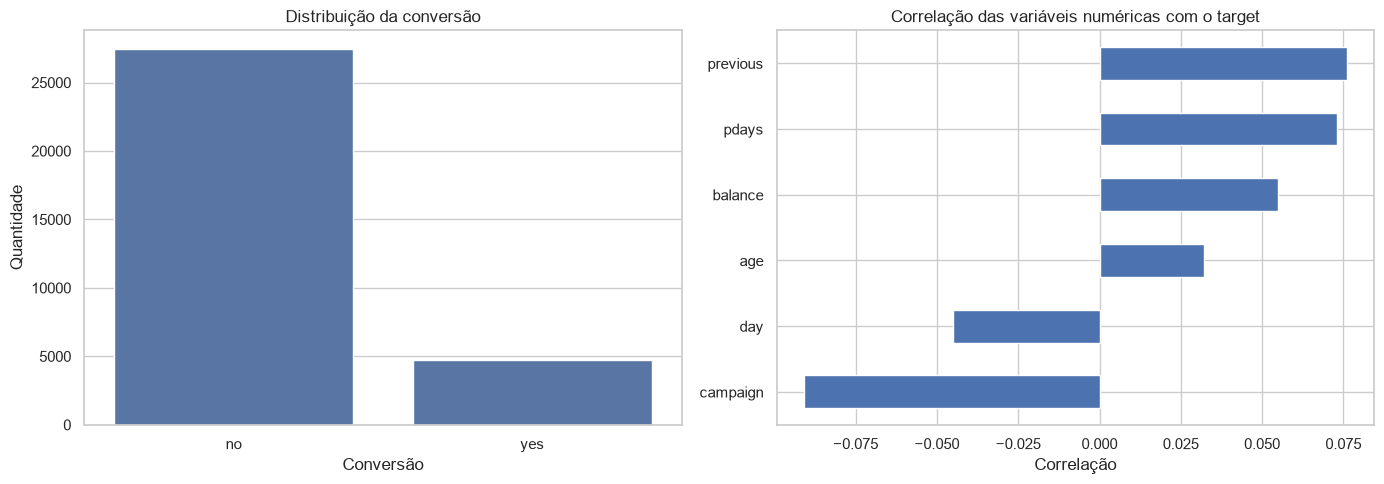

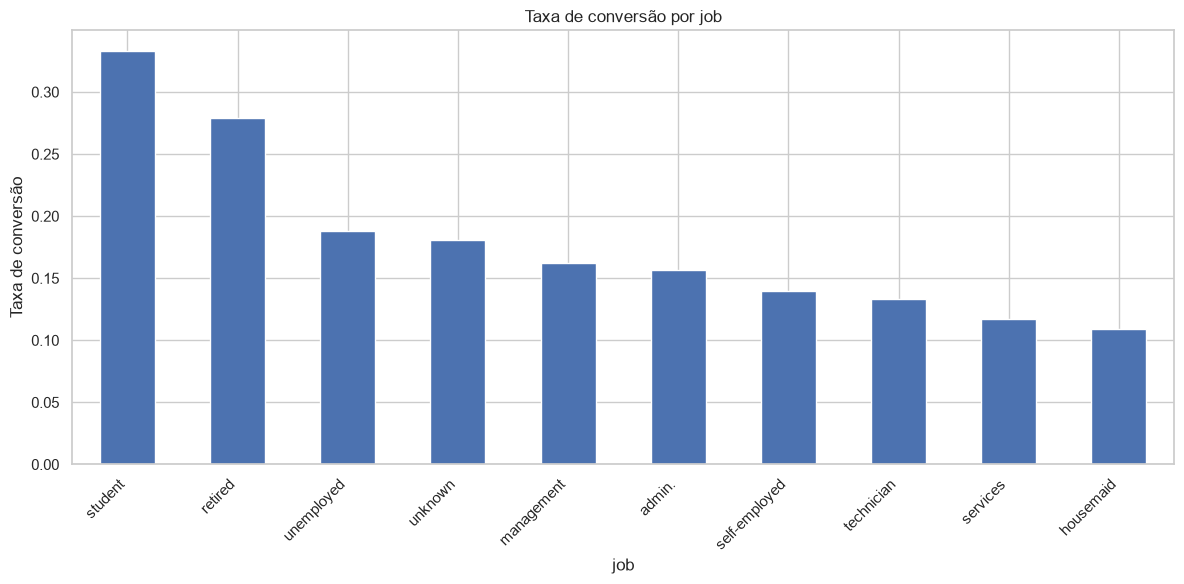

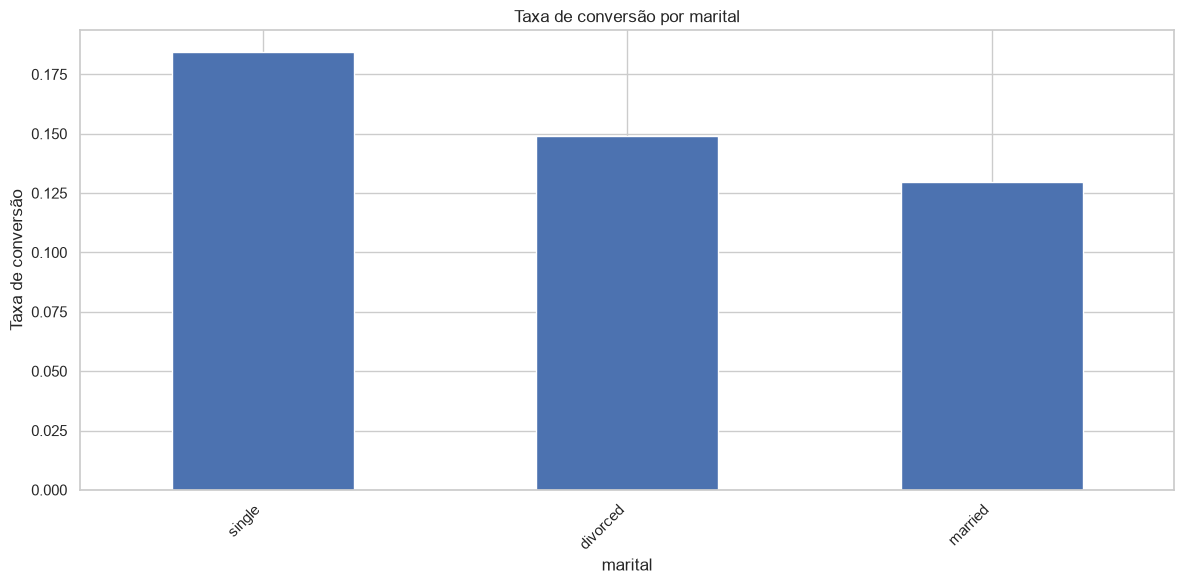

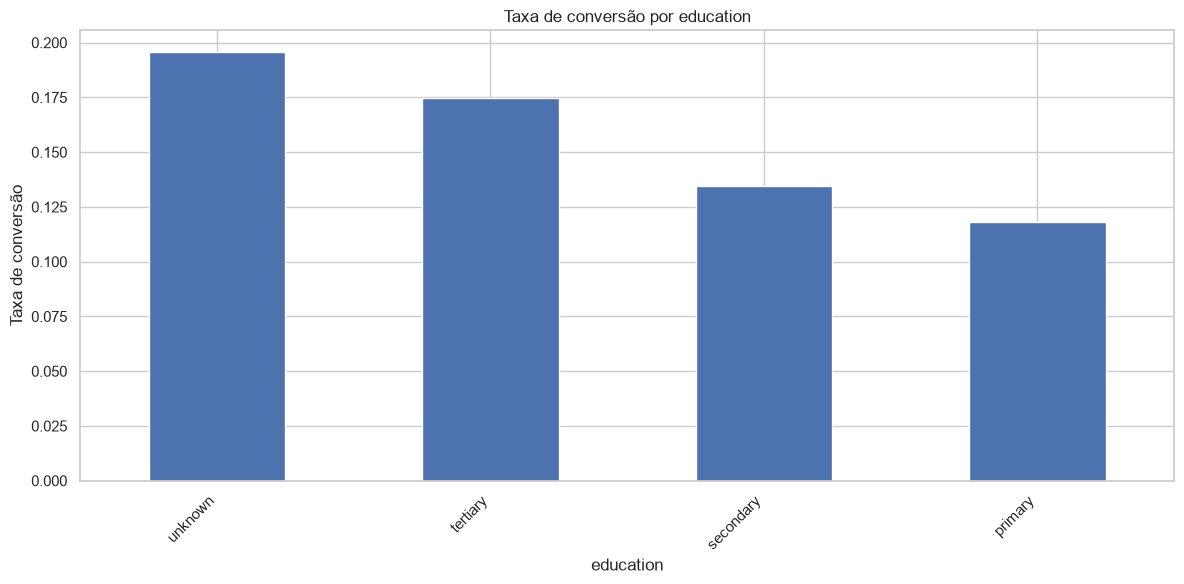

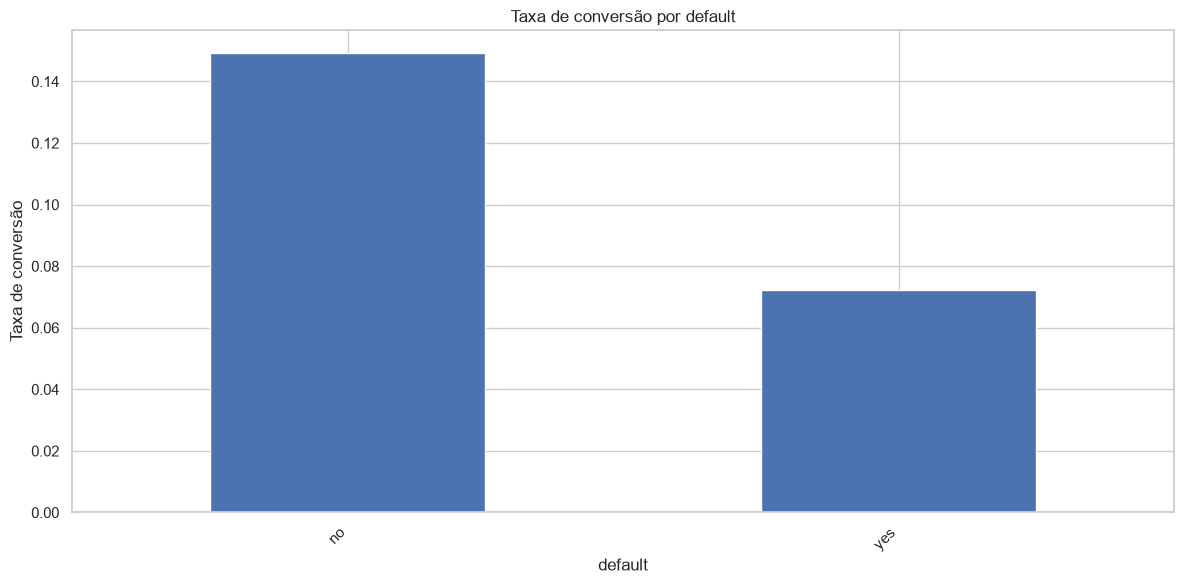

In [29]:
target_col = 'y'
target_numeric = df[target_col].map({'yes': 1, 'no': 0})

print('Resumo estatístico das variáveis numéricas:')
display(df.describe().T)

print('Distribuição do target:')
target_counts = df[target_col].value_counts(dropna=False)
display(target_counts.to_frame('quantidade'))

numeric_data = df.select_dtypes(include=np.number).copy()
numeric_data[target_col] = target_numeric
correlations = numeric_data.corr()[target_col].drop(target_col).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x=target_col, ax=axes[0])
axes[0].set_title('Distribuição da conversão')
axes[0].set_xlabel('Conversão')
axes[0].set_ylabel('Quantidade')

correlations.plot.barh(ax=axes[1])
axes[1].set_title('Correlação das variáveis numéricas com o target')
axes[1].set_xlabel('Correlação')
plt.tight_layout()
plt.show()

categorical_columns = df.select_dtypes(include='object').columns.drop(target_col, errors='ignore')
for column in categorical_columns[:4]:
    conversion_by_category = df.groupby(column)[target_col].apply(lambda values: (values == 'yes').mean()).sort_values(ascending=False).head(10)
    conversion_by_category.plot.bar(title=f'Taxa de conversão por {column}', ylabel='Taxa de conversão', xlabel=column)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()